#  Semantic Search pada Dataset Arsip
**Model:** DistilBERT | **Vector DB:** FAISS | **Evaluasi:** Precision@K

Notebook ini membangun sistem semantic search lengkap dengan alur:
1. Load & Preprocessing Dataset
2. Embedding dengan DistilBERT
3. Indexing dengan FAISS
4. Query & Similarity Search
5. Evaluasi Precision@K dan map@5 berbasis metadata-based pseudo ground truth 

##  Instalasi Library

In [97]:
# Install library yang dibutuhkan (khusus Kaggle environment)
!pip install -q faiss-cpu transformers openpyxl

## 1️. Import Library

In [98]:
import re
import time
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import AutoTokenizer, AutoModel
from IPython.display import display


# Reproducibility
torch.manual_seed(7)
np.random.seed(7)

print('✅ Semua library berhasil diimport')
print(f'   PyTorch version : {torch.__version__}')
print(f'   FAISS version   : {faiss.__version__}')
print(f'   Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

✅ Semua library berhasil diimport
   PyTorch version : 2.10.0+cu128
   FAISS version   : 1.15.0
   Device          : GPU


## 2️. identifikasi dataset

In [99]:
# ── Sesuaikan path dengan lokasi file di Kaggle ──
# Jika upload via Kaggle Datasets, path-nya:
# '/kaggle/input/<nama-dataset>/dataset_arsip.xlsx'
FILE_PATH = '/kaggle/input/datasets/muhammadhaekal74/dataset-arsip/dataset_arsip.xlsx'

# Load dataset
df = pd.read_excel(FILE_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris   : {len(df):,}')
print(f'   Jumlah kolom   : {len(df.columns)}')
print(f'   Kolom tersedia : {df.columns.tolist()}')
print()
display(df[['title', 'description', 'keywords', 'categoryId']].head(3))

✅ Dataset berhasil dimuat
   Jumlah baris   : 784
   Jumlah kolom   : 18
   Kolom tersedia : ['id', 'uuid', 'title', 'document_number', 'year', 'description', 'file_path', 'file_name', 'mime_type', 'file_size_kb', 'created_at', 'updated_at', 'uploaderId', 'categoryId', 'access_level', 'unitKerjaId', 'keywords', 'suratId']



,title,description,keywords,categoryId
0,Pengangkatan tim Perumus Visi dan Misi Univers...,Dokumen ini berisi tentang amanat Rektor perih...,"SK, Rektor, pengangkatan, tim perumus, visi da...",3
1,Visi dan Misi Universitas Darussalam Gontor,Dokumen ini berisi tentang Visi dan Misi Unive...,"SK, Keputusan, Rektor, Visi dan Misi, UNIDA",3
2,Penetapan Struktur Fungsionaris Centre For Isl...,Dokumen ini berisi tentang nama - nama yang di...,"SK, Rektor, Fungsionaris, CIES, UNIDA",3


## 3️. Pra pemrosesan data

In [100]:
def clean_text(text: str) -> str:
    """Bersihkan teks: lowercase, hapus karakter khusus, normalisasi spasi."""
    if not isinstance(text, str) or text.strip() == '':
        return ''
    text = text.lower()                          # Lowercase
    text = re.sub(r'[^a-z0-9\s]', ' ', text)    # Hapus karakter khusus
    text = re.sub(r'\s+', ' ', text).strip()     # Normalisasi spasi
    return text


def build_combined_text(row: pd.Series) -> str:
    """Gabungkan kolom title + description + keywords menjadi satu teks."""
    parts = [
        clean_text(str(row.get('title', ''))),
        clean_text(str(row.get('description', ''))),
        clean_text(str(row.get('keywords', '')))
    ]
    return ' '.join(p for p in parts if p)  # Abaikan bagian yang kosong


# Terapkan preprocessing
df['combined_text'] = df.apply(build_combined_text, axis=1)

# Hapus baris dengan teks kosong setelah preprocessing
df = df[df['combined_text'].str.strip() != ''].reset_index(drop=True)

print('✅ Preprocessing selesai')
print(f'   Dokumen valid  : {len(df):,}')
print()
print('Contoh combined_text (baris pertama):')
print(df['combined_text'].iloc[0])

✅ Preprocessing selesai
   Dokumen valid  : 784

Contoh combined_text (baris pertama):
pengangkatan tim perumus visi dan misi universitas darussalam gontor dokumen ini berisi tentang amanat rektor perihal pengangkatan nama nama terlampir sebagai tim perumus visi dan misi universitas darussalam gontor sk rektor pengangkatan tim perumus visi dan misi


## 4️. pembentukan Embedding dengan DistilBERT

In [101]:
# ── Konfigurasi Model ──────────────────────────────────────────
MODEL_NAME  = '/kaggle/input/models/muhammadhaekal74/distilbert-finetuned-/pytorch/default/1'   # DistilBERT versi Bahasa Indonesia
BATCH_SIZE  = 32                           # Sesuaikan dengan RAM/VRAM
MAX_LENGTH  = 256                          # Panjang maksimum token input
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load tokenizer dan model
print(f'🔄 Memuat model "{MODEL_NAME}" ke {DEVICE.upper()}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print('✅ Model berhasil dimuat')

🔄 Memuat model "/kaggle/input/models/muhammadhaekal74/distilbert-finetuned-/pytorch/default/1" ke CUDA...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

✅ Model berhasil dimuat


In [102]:
def mean_pooling(model_output, attention_mask):
    """
    Mean Pooling: rata-rata token embedding yang valid (bukan padding).
    Menghasilkan satu vektor representasi per kalimat.
    """
    token_embeddings = model_output.last_hidden_state          # (B, L, H)
    mask_expanded    = attention_mask.unsqueeze(-1).float()    # (B, L, 1)
    sum_embeddings   = (token_embeddings * mask_expanded).sum(1)  # (B, H)
    sum_mask         = mask_expanded.sum(1).clamp(min=1e-9)       # (B, 1)
    return sum_embeddings / sum_mask                              # (B, H)


def encode_texts(texts: list, batch_size: int = BATCH_SIZE) -> np.ndarray:
    """
    Ubah daftar teks menjadi matriks embedding (N × D).
    Diproses secara batch untuk efisiensi memori.
    """
    all_embeddings = []

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start : start + batch_size]

        # Tokenisasi batch
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors='pt'
        ).to(DEVICE)

        # Inferensi tanpa gradient (hemat memori)
        with torch.no_grad():
            output = model(**encoded)

        # Mean pooling → pindahkan ke CPU → konversi ke numpy
        embeddings = mean_pooling(output, encoded['attention_mask'])
        all_embeddings.append(embeddings.cpu().numpy())

        # Progress setiap 100 batch
        batch_num = start // batch_size + 1
        total_batches = (len(texts) + batch_size - 1) // batch_size
        if batch_num % 5 == 0 or batch_num == total_batches:
            print(f'   Batch {batch_num:>3}/{total_batches} selesai '
                  f'({min(start+batch_size, len(texts))}/{len(texts)} teks)')

    return np.vstack(all_embeddings).astype(np.float32)


# Encode semua dokumen
print('🔄 Membuat embedding untuk seluruh dokumen...')
doc_embeddings = encode_texts(df['combined_text'].tolist())

print()
print('✅ Embedding selesai')
print(f'   Shape embedding : {doc_embeddings.shape}  (dokumen × dimensi)')

🔄 Membuat embedding untuk seluruh dokumen...
   Batch   5/25 selesai (160/784 teks)
   Batch  10/25 selesai (320/784 teks)
   Batch  15/25 selesai (480/784 teks)
   Batch  20/25 selesai (640/784 teks)
   Batch  25/25 selesai (784/784 teks)

✅ Embedding selesai
   Shape embedding : (784, 768)  (dokumen × dimensi)


## 5️. Normalisasi & Indexing FAISS (Cosine Similarity)

In [103]:
# Normalisasi L2 → Inner Product menjadi setara dengan Cosine Similarity
faiss.normalize_L2(doc_embeddings)

# Buat FAISS index dengan Inner Product (cosine setelah normalisasi)
EMBEDDING_DIM = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(EMBEDDING_DIM)   # IP = Inner Product

# Tambahkan semua embedding ke index
index.add(doc_embeddings)

print('✅ FAISS index berhasil dibuat')
print(f'   Tipe index        : IndexFlatIP (Cosine Similarity)')
print(f'   Dimensi embedding : {EMBEDDING_DIM}')
print(f'   Total vektor      : {index.ntotal:,}')

✅ FAISS index berhasil dibuat
   Tipe index        : IndexFlatIP (Cosine Similarity)
   Dimensi embedding : 768
   Total vektor      : 784


## 6️. Penyusunan Query uji

In [104]:
TOP_K = 5   # Jumlah dokumen teratas yang diambil

# ── Metadata-Based Pseudo Ground Truth ───────────────────────────────────────
# Label relevansi setiap query ditetapkan berdasarkan metadata categoryId
# yang tersedia pada dataset SEBELUM proses retrieval dijalankan.


# Referensi kategori:
# categoryId 1 → Foto & Dokumentasi (77 dok)
# categoryId 3 → SK & Kebijakan Universitas (324 dok)
# categoryId 4 → Surat Menyurat & Kunjungan (19 dok)
# categoryId 5 → Akreditasi & Sertifikasi (57 dok)
# categoryId 6 → Panduan & Pedoman Akademik (75 dok)
# categoryId 7 → Laporan Kegiatan (25 dok)
# categoryId 8 → SOP & Anggaran (207 dok)

QUERY_GROUND_TRUTH = {
    'pengangkatan rektor universitas'        : 3,  # SK & Kebijakan Universitas
    'surat keputusan fakultas'               : 3,  # SK & Kebijakan Universitas
    'surat pernyataan'                       : 3,  # SK & Kebijakan Universitas
    'sertifikasi akreditasi program studi'   : 5,  # Akreditasi & Sertifikasi
    'anggaran kegiatan'                      : 8,  # SOP & Anggaran
    'standar operasional prosedur instansi'  : 8,  # SOP & Anggaran
    'laporan kegiatan workshop sosialisasi'  : 7,  # Laporan Kegiatan
}

SAMPLE_QUERIES = list(QUERY_GROUND_TRUTH.keys())


def search(query: str, k: int = TOP_K) -> tuple:
    """
    Cari dokumen paling relevan untuk satu query.

    Returns:
        indices: indeks baris di DataFrame
        scores : cosine similarity score (0–1)
    """
    # Preprocessing query (sama dengan dokumen)
    clean_query  = clean_text(query)

    # Encode query menjadi embedding
    query_vector = encode_texts([clean_query])   # shape: (1, D)
    faiss.normalize_L2(query_vector)              # Normalisasi L2

    # Cari Top-K dokumen terdekat di FAISS index
    scores, indices = index.search(query_vector, k)

    return indices[0], scores[0]


print(f'✅ Query uji dan ground truth siap. TOP_K = {TOP_K}')
print(f'   Jumlah query uji : {len(SAMPLE_QUERIES)}')
print()
print('Daftar query dan ground truth category:')
for q, cat in QUERY_GROUND_TRUTH.items():
    print(f'  [{cat}] {q}')

✅ Query uji dan ground truth siap. TOP_K = 5
   Jumlah query uji : 7

Daftar query dan ground truth category:
  [3] pengangkatan rektor universitas
  [3] surat keputusan fakultas
  [3] surat pernyataan
  [5] sertifikasi akreditasi program studi
  [8] anggaran kegiatan
  [8] standar operasional prosedur instansi
  [7] laporan kegiatan workshop sosialisasi


## 7️. Evaluasi sistem (Precision@K)

In [105]:
def precision_at_k(relevant_category: int, result_indices: np.ndarray, k: int) -> float:
    """
    Hitung Precision@K menggunakan metadata-based pseudo ground truth.

    Relevansi ditentukan berdasarkan categoryId yang ditetapkan
    sebelum proses retrieval dijalankan (independen dari keluaran model).

    Formula:
        Precision@K = (# dokumen relevan dalam Top-K) / K
    """
    top_k_indices    = result_indices[:k]
    top_k_categories = df.loc[top_k_indices, 'categoryId'].values

    num_relevant = np.sum(top_k_categories == relevant_category)

    return num_relevant / k


print('✅ Fungsi precision_at_k siap')

✅ Fungsi precision_at_k siap


## 7.1 Average Precision at 5 (AP@5)

In [106]:
def average_precision_at_k(
    relevant_category: int,
    result_indices: np.ndarray,
    k: int = TOP_K
) -> float:
    """
    Menghitung Average Precision@K (AP@K).

    AP@K dihitung sebagai rata-rata nilai Precision pada setiap posisi
    di mana dokumen relevan ditemukan dalam Top-K hasil retrieval.

    Formula:
        AP@K = (Σ Precision@i) / H

    dengan:
        H = jumlah dokumen relevan yang ditemukan pada Top-K
    """

    # Ambil hanya Top-K hasil retrieval
    top_indices = result_indices[:k]
    categories = df.loc[top_indices, 'categoryId'].values

    relevant_hits = 0
    precision_sum = 0.0

    for rank, cat in enumerate(categories, start=1):
        if cat == relevant_category:
            relevant_hits += 1
            precision_sum += relevant_hits / rank

    if relevant_hits == 0:
        return 0.0

    return precision_sum / relevant_hits


print("✅ Fungsi average_precision_at_k (AP@5) siap")

✅ Fungsi average_precision_at_k (AP@5) siap


## 8️. Perankingan ahsil pencarian

In [107]:
# Mapping categoryId ke nama kategori
CATEGORY_NAMES = {
    1: 'Foto & Dokumentasi',
    3: 'SK & Kebijakan Universitas',
    4: 'Surat Menyurat & Kunjungan',
    5: 'Akreditasi & Sertifikasi',
    6: 'Panduan & Pedoman Akademik',
    7: 'Laporan Kegiatan',
    8: 'SOP & Anggaran',
}


def run_and_display(query: str, k: int = TOP_K):
    """Jalankan search untuk satu query dan tampilkan hasil lengkap."""

    # ── Pencarian ─────────────────────────────────────────────────────────────
    indices, scores = search(query, k)

    # ── Metadata-Based Pseudo Ground Truth (independen dari keluaran model) ───
    relevant_category = QUERY_GROUND_TRUTH[query]

    # ── Precision@5 dan AP@5 ──────────────────────────────────────────────────
    prec_at_k = precision_at_k(relevant_category, indices, k)
    ap_score  = average_precision_at_k(relevant_category, indices, k)

    # ── Tampilkan Header ──────────────────────────────────────────────────────
    sep = '═' * 78
    print(sep)
    print(f'   QUERY   : "{query}"')
    print(f'  📊 Precision@{k} : {prec_at_k:.2%}   |   AP@{k} : {ap_score:.2%}   '
          f'(ground truth category = {relevant_category})')
    print(sep)

    # ── Tampilkan Top-K Hasil ─────────────────────────────────────────────────
    rows = []
    for rank, (idx, score) in enumerate(zip(indices, scores), start=1):
        row      = df.loc[idx]
        cat_id   = row['categoryId']
        cat_name = CATEGORY_NAMES.get(cat_id, f'Cat-{cat_id}')
        relevant = '✅' if cat_id == relevant_category else '❌'

        rows.append({
            'Rank'      : rank,
            'Score'     : f'{score:.4f}',
            'Relevan'   : relevant,
            'CategoryId': cat_id,
            'Category'  : cat_name,
            'Title': str(row['title']),
        })
        
    pd.set_option('display.max_colwidth', None)

    result_df = pd.DataFrame(rows).set_index('Rank')
    display(result_df)
    print()

    return prec_at_k, ap_score


# ── Jalankan semua query ───────────────────────────────────────────────────────
print('🚀 Menjalankan semantic search untuk semua query...\n')
all_precision = []
all_ap        = []

for q in SAMPLE_QUERIES:
    p, ap = run_and_display(q, k=TOP_K)
    all_precision.append(p)
    all_ap.append(ap)

🚀 Menjalankan semantic search untuk semua query...

   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "pengangkatan rektor universitas"
  📊 Precision@5 : 100.00%   |   AP@5 : 100.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.7914,✅,3,SK & Kebijakan Universitas,Pengangkatan Staff Pembantu Kegiatan Harian
2,0.7867,✅,3,SK & Kebijakan Universitas,Penetapan Dosen Pembimbing Skripsi Prodi Manajemen
3,0.7847,✅,3,SK & Kebijakan Universitas,Pengangkatan Rektor
4,0.7808,✅,3,SK & Kebijakan Universitas,Pemberlakuan Program Proofreading Bahasa Tugas Akhir
5,0.7775,✅,3,SK & Kebijakan Universitas,Penetapan Dosen Pembimbing Skripsi Prodi Manajemen



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "surat keputusan fakultas"
  📊 Precision@5 : 100.00%   |   AP@5 : 100.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.8469,✅,3,SK & Kebijakan Universitas,Penetapan Organisasi Tata Kelola Biro Kerjasama dan Urusan Internasional
2,0.8452,✅,3,SK & Kebijakan Universitas,Surat Keputusan Rektor tentang Penetapan Penanggung Jawab Penerimaan Mahasiswa Baru setiap Program Studi
3,0.8385,✅,3,SK & Kebijakan Universitas,Surat Keputusan Rektor tentang Pengangkatan Panitia UTS Gasal 2025
4,0.8367,✅,3,SK & Kebijakan Universitas,Kelompok Konsorsium Dosen Prodi Perbandingan Madzhab
5,0.8304,✅,3,SK & Kebijakan Universitas,Konsorsium Dosen Rumpun Mata Kuliah Fakultas Ekonomi dan Manajemen



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "surat pernyataan"
  📊 Precision@5 : 100.00%   |   AP@5 : 100.00%   (ground truth category = 3)
══════════════════════════════════════════════════════════════════════════════


...

,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.6941,✅,8,SOP & Anggaran,SOP Pelaksanaan Kegiatan Mahasiswa
2,0.6924,✅,8,SOP & Anggaran,SOP Pengajuan Anggaran
3,0.6862,❌,3,SK & Kebijakan Universitas,ARSIP REVIEWER HIBAH INTERNAL RELASI
4,0.6841,✅,8,SOP & Anggaran,SOP Penggunaan Laboratorium
5,0.6737,✅,8,SOP & Anggaran,SOP PENGADAAN PERLENGKAPAN KANTOR



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "standar operasional prosedur instansi"
  📊 Precision@5 : 100.00%   |   AP@5 : 100.00%   (ground truth category = 8)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.8502,✅,8,SOP & Anggaran,SOP Praktikum Laboratorium
2,0.8453,✅,8,SOP & Anggaran,SOP Pelayanan Pasien Sakit
3,0.8413,✅,8,SOP & Anggaran,SOP Pengajuan Anggaran
4,0.8321,✅,8,SOP & Anggaran,"SOP Pembuatan Visi, Misi, dan Strategi Fakultas"
5,0.8119,✅,8,SOP & Anggaran,SOP Perubahan Nilai Mata Kuliah



   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "laporan kegiatan workshop sosialisasi"
  📊 Precision@5 : 100.00%   |   AP@5 : 100.00%   (ground truth category = 7)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.9600,✅,7,Laporan Kegiatan,LAPORAN KEGIATAN SOSIALISASI DAN WORKSHOP
2,0.9464,✅,7,Laporan Kegiatan,Review Kurikulum Prodi TBI bersama Bapak Yanuar Universitas Lampung
3,0.9435,✅,7,Laporan Kegiatan,Naskah Soal Ujian Akhir Semester Genap 2022-2023 Prodi Keselamatan dan Kesehatan Kerja
4,0.9420,✅,7,Laporan Kegiatan,Kunjungan Kepala Kantor Urusan Internasional Cordoba University Spanyol dan International Guest Lecturer di UNIDA Gontor
5,0.9413,✅,7,Laporan Kegiatan,Laporan Kegiatan Workshop Tata Kelola Memori Kolektif Bangsa_FKMSA


## 9️. Ringkasan Evaluasi — Precision@5 dan MAP@5

In [108]:
# ── Tampilkan ringkasan evaluasi semua query ──────────────────────────────────
summary = pd.DataFrame({
    'Query'              : SAMPLE_QUERIES,
    f'Precision@{TOP_K}' : [f'{p:.2%}' for p in all_precision],
    f'AP@{TOP_K}'        : [f'{a:.2%}' for a in all_ap]
})

mean_precision = np.mean(all_precision)
map_score      = np.mean(all_ap)

print('=' * 55)
print(f'   RINGKASAN EVALUASI')
print('=' * 55)
display(summary)
print()
print(f'  ✅ Mean Precision@{TOP_K} : {mean_precision:.2%}')
print(f'  ✅ MAP@{TOP_K}            : {map_score:.2%}')
print('=' * 55)

   RINGKASAN EVALUASI


,Query,Precision@5,AP@5
0,pengangkatan rektor universitas,100.00%,100.00%
1,surat keputusan fakultas,100.00%,100.00%
2,surat pernyataan,100.00%,100.00%
3,sertifikasi akreditasi program studi,100.00%,100.00%
4,anggaran kegiatan,80.00%,88.75%
5,standar operasional prosedur instansi,100.00%,100.00%
6,laporan kegiatan workshop sosialisasi,100.00%,100.00%



  ✅ Mean Precision@5 : 97.14%
  ✅ MAP@5            : 98.39%


## 9.1 Pengukuran Query Latency

In [109]:
# ── Pengukuran Query Latency 
# Query latency = waktu total yang dibutuhkan sistem untuk memproses satu query
# Mencakup: preprocessing → encoding → normalisasi → FAISS search

latencies_ms = []

for q in SAMPLE_QUERIES:
    start = time.time()                          # Mulai stopwatch

    clean_q      = clean_text(q)                 # Preprocessing
    query_vector = encode_texts([clean_q])        # Encoding (DistilBERT)
    faiss.normalize_L2(query_vector)              # Normalisasi L2
    _, _ = index.search(query_vector, TOP_K)      # FAISS search

    latency_ms = (time.time() - start) * 1000    # Konversi ke milidetik
    latencies_ms.append(latency_ms)

# ── Hasil Pengukuran 
avg_latency  = np.mean(latencies_ms)
min_latency  = np.min(latencies_ms)
max_latency  = np.max(latencies_ms)
throughput   = 1000 / avg_latency               # queries per detik

# ── Tabel Latency per Query 
latency_df = pd.DataFrame({
    'Query'         : SAMPLE_QUERIES,
    'Latency (ms)'  : [f'{l:.2f}' for l in latencies_ms]
})
display(latency_df)

# ── Ringkasan
print('=' * 55)
print('   RINGKASAN QUERY LATENCY')
print('=' * 55)
print(f'     Avg Latency  : {avg_latency:.2f} ms')
print(f'     Min Latency  : {min_latency:.2f} ms')
print(f'     Max Latency  : {max_latency:.2f} ms')
print(f'     Throughput   : {throughput:.2f} queries/detik')
print('=' * 55)

   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)
   Batch   1/1 selesai (1/1 teks)


,Query,Latency (ms)
0,pengangkatan rektor universitas,6.27
1,surat keputusan fakultas,5.20
2,surat pernyataan,4.34
3,sertifikasi akreditasi program studi,5.37
4,anggaran kegiatan,4.41
5,standar operasional prosedur instansi,5.10
6,laporan kegiatan workshop sosialisasi,4.54


   RINGKASAN QUERY LATENCY
     Avg Latency  : 5.03 ms
     Min Latency  : 4.34 ms
     Max Latency  : 6.27 ms
     Throughput   : 198.71 queries/detik


## 9.2 Eksperimen Multi-Seed (Uji Determinisme Sistem)

## 9.3 Visualisasi Evaluasi

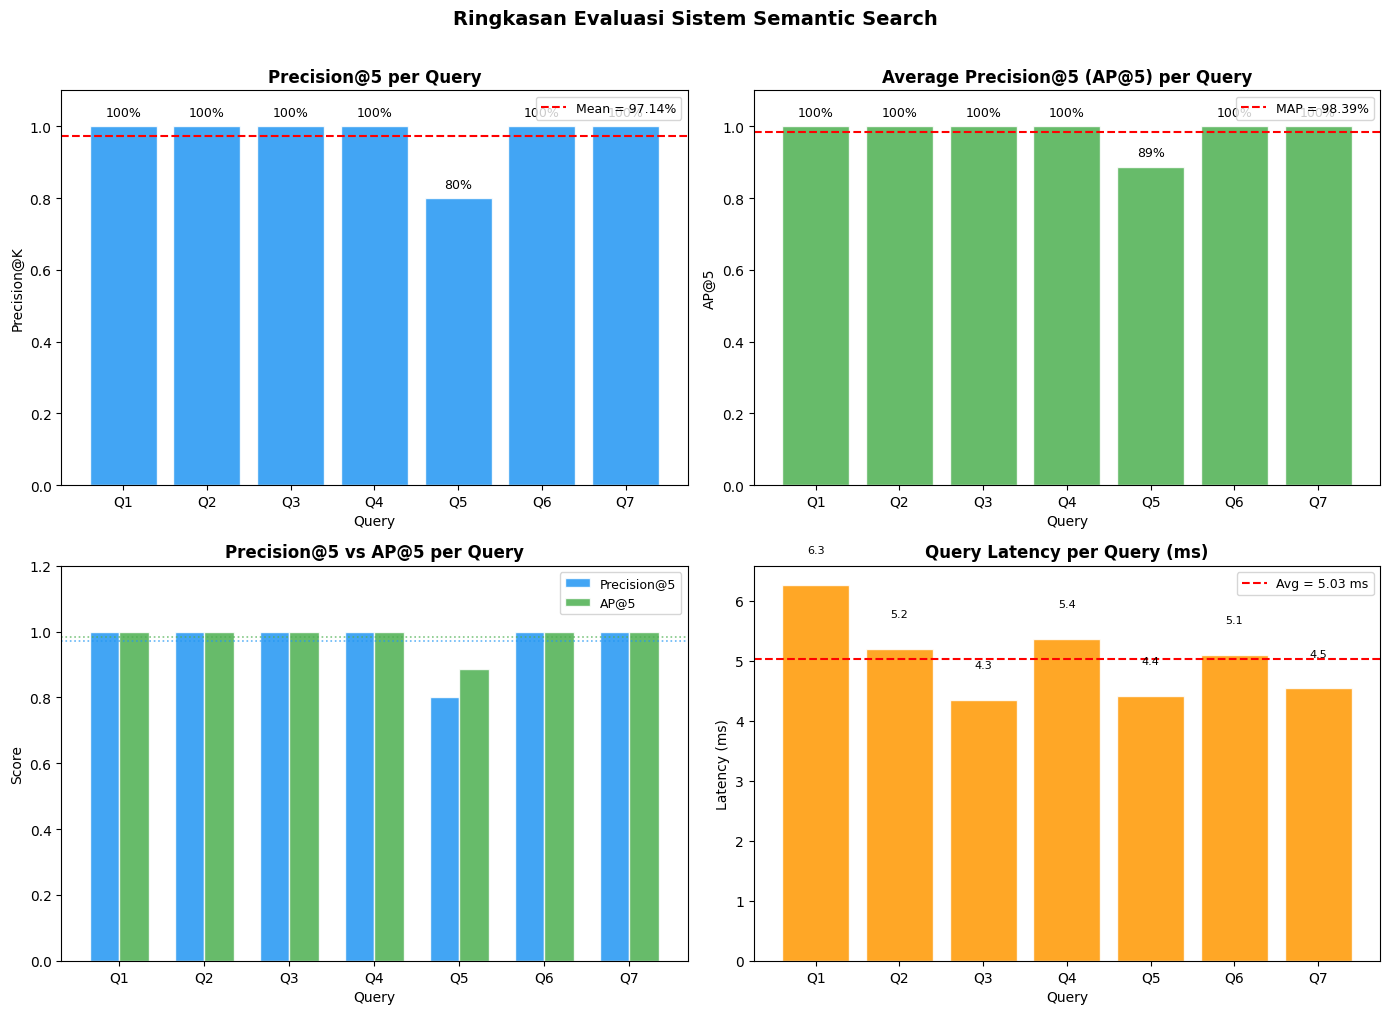

   RINGKASAN METRIK EVALUASI
  📊 Mean Precision@5 : 97.14%
  📊 MAP@5           : 98.39%
  ⏱  Avg Latency       : 5.03 ms
  ⚡ Throughput        : 198.71 queries/detik
✅ Visualisasi tersimpan: evaluasi_semantic_search.png


In [110]:
# ── Data dari hasil evaluasi sebelumnya ──────────────────────────────────────
queries_short = [f'Q{i+1}' for i in range(len(SAMPLE_QUERIES))]  # Q1, Q2, ..., Q7
precision_vals = all_precision
ap_vals        = all_ap
latency_vals   = latencies_ms

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ringkasan Evaluasi Sistem Semantic Search', fontsize=14, fontweight='bold', y=1.01)

# ── Warna ─────────────────────────────────────────────────────────────────────
COLOR_PRECISION = '#2196F3'
COLOR_AP        = '#4CAF50'
COLOR_LATENCY   = '#FF9800'
COLOR_MAP       = '#9C27B0'

# ── Plot 1: Precision@K per Query ────────────────────────────────────────────
ax1 = axes[0, 0]
bars1 = ax1.bar(queries_short, precision_vals, color=COLOR_PRECISION, alpha=0.85, edgecolor='white')
ax1.axhline(y=np.mean(precision_vals), color='red', linestyle='--', linewidth=1.5, label=f'Mean = {np.mean(precision_vals):.2%}')
ax1.set_title(f'Precision@{TOP_K} per Query', fontweight='bold')
ax1.set_xlabel('Query')
ax1.set_ylabel('Precision@K')
ax1.set_ylim(0, 1.1)
ax1.legend(fontsize=9)
for bar, val in zip(bars1, precision_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# ── Plot 2: Average Precision (AP) per Query ─────────────────────────────────
ax2 = axes[0, 1]
bars2 = ax2.bar(queries_short, ap_vals, color=COLOR_AP, alpha=0.85, edgecolor='white')
ax2.axhline(y=np.mean(ap_vals), color='red', linestyle='--', linewidth=1.5, label=f'MAP = {np.mean(ap_vals):.2%}')
ax2.set_title(f'Average Precision@{TOP_K} (AP@{TOP_K}) per Query', fontweight='bold')
ax2.set_xlabel('Query')
ax2.set_ylabel(f'AP@{TOP_K}')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
for bar, val in zip(bars2, ap_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.0%}', ha='center', va='bottom', fontsize=9)

# ── Plot 3: Precision@K vs AP (perbandingan per query) ───────────────────────
ax3 = axes[1, 0]
x    = np.arange(len(queries_short))
w    = 0.35
bar3a = ax3.bar(x - w/2, precision_vals, w, label=f'Precision@{TOP_K}', color=COLOR_PRECISION, alpha=0.85, edgecolor='white')
bar3b = ax3.bar(x + w/2, ap_vals,        w, label=f'AP@{TOP_K}',                  color=COLOR_AP,        alpha=0.85, edgecolor='white')
ax3.set_title(f'Precision@{TOP_K} vs AP@{TOP_K} per Query', fontweight='bold')
ax3.set_xlabel('Query')
ax3.set_ylabel('Score')
ax3.set_ylim(0, 1.2)
ax3.set_xticks(x)
ax3.set_xticklabels(queries_short)
ax3.legend(fontsize=9)
ax3.axhline(y=np.mean(precision_vals), color=COLOR_PRECISION, linestyle=':', linewidth=1.2, alpha=0.7)
ax3.axhline(y=np.mean(ap_vals),        color=COLOR_AP,        linestyle=':', linewidth=1.2, alpha=0.7)

# ── Plot 4: Query Latency per Query ──────────────────────────────────────────
ax4 = axes[1, 1]
bars4 = ax4.bar(queries_short, latency_vals, color=COLOR_LATENCY, alpha=0.85, edgecolor='white')
ax4.axhline(y=np.mean(latency_vals), color='red', linestyle='--', linewidth=1.5,
            label=f'Avg = {np.mean(latency_vals):.2f} ms')
ax4.set_title('Query Latency per Query (ms)', fontweight='bold')
ax4.set_xlabel('Query')
ax4.set_ylabel('Latency (ms)')
ax4.legend(fontsize=9)
for bar, val in zip(bars4, latency_vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('evaluasi_semantic_search.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan akhir ───────────────────────────────────────────────────────────
print('=' * 55)
print('   RINGKASAN METRIK EVALUASI')
print('=' * 55)
print(f'  📊 Mean Precision@{TOP_K} : {np.mean(precision_vals):.2%}')
print(f'  📊 MAP@{TOP_K}           : {np.mean(ap_vals):.2%}')
print(f'  ⏱  Avg Latency       : {np.mean(latency_vals):.2f} ms')
print(f'  ⚡ Throughput        : {1000/np.mean(latency_vals):.2f} queries/detik')
print('=' * 55)
print('✅ Visualisasi tersimpan: evaluasi_semantic_search.png')

## 10. Interactive Search


In [111]:
# Referensi kategori:
# categoryId 1 → Foto & Dokumentasi (77 dok)
# categoryId 3 → SK & Kebijakan Universitas (324 dok)
# categoryId 4 → Surat Menyurat & Kunjungan (19 dok)
# categoryId 5 → Akreditasi & Sertifikasi (57 dok)
# categoryId 6 → Panduan & Pedoman Akademik (75 dok)
# categoryId 7 → Laporan Kegiatan (25 dok)
# categoryId 8 → SOP & Anggaran (207 dok)
CUSTOM_QUERY      = 'kegiatan tahunan akademik'
CUSTOM_CATEGORY   = 7   # sesuaikan dengan categoryId yang relevan

# Daftarkan ke ground truth sementara
QUERY_GROUND_TRUTH[CUSTOM_QUERY] = CUSTOM_CATEGORY

p, ap = run_and_display(CUSTOM_QUERY, k=TOP_K)

   Batch   1/1 selesai (1/1 teks)
══════════════════════════════════════════════════════════════════════════════
   QUERY   : "kegiatan tahunan akademik"
  📊 Precision@5 : 80.00%   |   AP@5 : 88.75%   (ground truth category = 7)
══════════════════════════════════════════════════════════════════════════════


,Score,Relevan,CategoryId,Category,Title
Rank,,,,,
1,0.7875,✅,7,Laporan Kegiatan,Lapiran Kegiatan Monitoring dan Evaluasi Kinerja Akhir Tahun 2024/2025 Fakultas Sains dan Teknologi
2,0.7873,✅,7,Laporan Kegiatan,Laporan Kegiatan Yudisium Fakultas Sains dan Teknologi Tahun 2024/2025
3,0.7831,❌,6,Panduan & Pedoman Akademik,Pedoman Perencanaan Pengembangan dan Monitoring Kerjasama Unida
4,0.7764,✅,7,Laporan Kegiatan,Laporan Kegiatan Survey Kepuasan Mitra Kerjasama UNIDA Gontor 2024
5,0.7735,✅,7,Laporan Kegiatan,Laporan Kegiatan Benchmarking LP2IP ke Universitas Muhammadiyah Ponorogo
